In [ ]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

from concurrent.futures import ThreadPoolExecutor
import os

import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

from scripts.constants import PI, s2  # type: ignore
from scripts.utils import is_hermitian

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

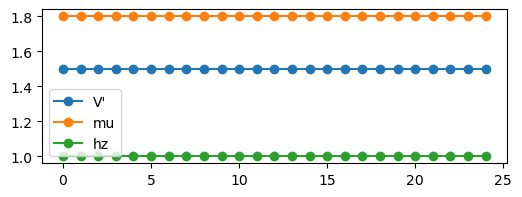

In [3]:
widthP = 25

X, Y = widthP, 100
lattice = Lattice(X, Y)

t = 1
T = 0.02

muS = 1.2 * t
muP = 1.8 * t
muF = 1.4 * t
mu = np.ones(lattice.X) * muP

hz0 = 1 * t
hz = np.ones_like(mu) * hz0

hx0 = 1 * t
hx = np.ones_like(mu) * hx0

hy0 = 1 * t
hy = np.ones_like(mu) * hy0


V0 = 1.5 * t
V_prime = V0 * np.ones(lattice.X)
# V_prime[:widthF+widthS] = 0 
U = None
V = None

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, '-o', label='mu')
plt.plot(hz, '-o', label='hz')

plt.legend()

In [ ]:
H = Hamiltonian(t, mu, lattice, 
                U=U, V_prime=V_prime, V=None,
                Fuu_init=[0.1, -0.1, 0.1j, -0.1j],
                Fdd_init=[0.1, -0.1, 0.1j, -0.1j],
                hy=hy)

In [5]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, rtol=0.1, atol=1e-3, maxiter=100, verbose=True, temperature=T)
F, Fuu, Fdd = H.get_correlations()

F0:
Absolute error: 1.4795637464544245e-15
Relative error: 0.0014795637464544245
Average old: 0j
Average: (-1.0713369888546032e-17+0j)
F_xplus:
Absolute error: 0.1200234559206294
Relative error: 120023455920.62941
Average old: 0j
Average: (0.02425585702340824+0j)
F_xmin:
Absolute error: 0.12002345592062971
Relative error: 120023455920.62971
Average old: 0j
Average: (-0.024255857023408295+0j)
F_yplus:
Absolute error: 0.15102115432027477
Relative error: 151021154320.27475
Average old: 0j
Average: (-2.782428446115515e-17+0.029309238896044594j)
F_ymin:
Absolute error: 0.15102115432027477
Relative error: 151021154320.27475
Average old: 0j
Average: (-2.782428446115515e-17-0.029309238896044594j)
Fuu_xplus:
Absolute error: 0.09390106549537537
Relative error: 0.9390106549443634
Average old: (0.09999999999999999+0j)
Average: (0.1154528294128129+0j)
Fuu_xmin:
Absolute error: 0.09390106549537534
Relative error: 0.9390106549631436
Average old: (-0.09999999999999999+0j)
Average: (-0.1154528294128129

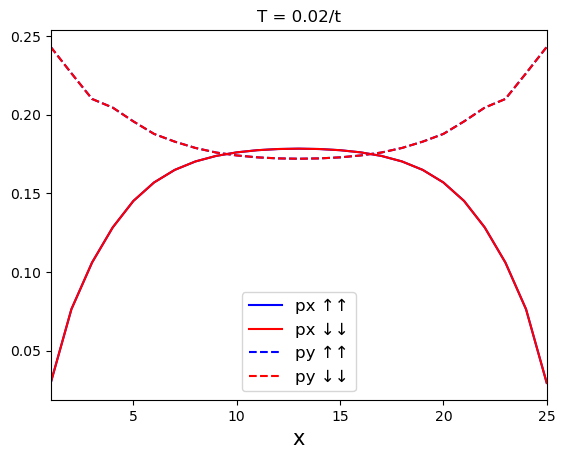

In [6]:
x = np.arange(1, X + 1)
F0 = H.F0
plt.title(f"T = {T}/t")
plt.plot(x, np.real(Fuu.px), label="px ↑↑", color='blue')
plt.plot(x, np.real(Fdd.px), label="px ↓↓", color='red')
plt.plot(x, np.imag(Fuu.py), "--", label="py ↑↑", color='blue')
plt.plot(x, np.imag(Fdd.py), "--", label="py ↓↓", color='red')
plt.xlabel("x", fontsize=15)
plt.xlim(1, X)
plt.legend(fontsize=12, loc="best")

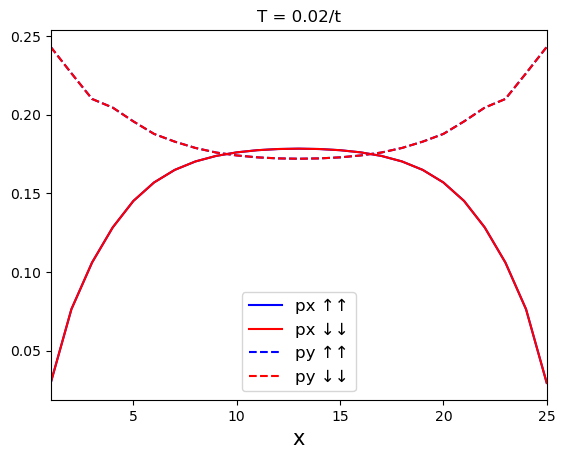

In [7]:
x = np.arange(1, X + 1)
F0 = H.F0
plt.title(f"T = {T}/t")
plt.plot(x, np.abs(Fuu.px), label="px ↑↑", color='blue')
plt.plot(x, np.abs(Fdd.px), label="px ↓↓", color='red')
plt.plot(x, np.abs(Fuu.py), "--", label="py ↑↑", color='blue')
plt.plot(x, np.abs(Fdd.py), "--", label="py ↓↓", color='red')
plt.xlabel("x", fontsize=15)
plt.xlim(1, X)
plt.legend(fontsize=12, loc="best")